GPU memory configuration and Library importing


In [ ]:
# GPU Memory Configuration
from tensorflow.compat.v1 import ConfigProto, InteractiveSession

gpu_config = ConfigProto()
gpu_config.gpu_options.per_process_gpu_memory_fraction = 0.5
gpu_config.gpu_options.allow_growth = True
session = InteractiveSession(config=gpu_config)

# Imports
import gdown
import urllib.request
import zipfile
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
from glob import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns



ERROR:tensorflow:An interactive session is already active. This can cause out-of-memory errors or some other unexpected errors (due to the unpredictable timing of garbage collection) in some cases. You must explicitly call `InteractiveSession.close()` to release resources held by the other session(s). Please use `tf.Session()` if you intend to productionize.


Loading Dataset


In [ ]:
# Load the dataset

#
file_id = "1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA"
gdown.download(f"https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA", "cotton_disease_dataset.zip", quiet=False)




Downloading...
From (original): https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA
From (redirected): https://drive.google.com/uc?id=1jWtJcoEWKCxA58mD31FbsOhFajOCUSwA&confirm=t&uuid=e80404b7-4544-4f46-9097-3e80385789e3
To: /content/cotton_disease_dataset.zip
100%|██████████| 162M/162M [00:04<00:00, 37.9MB/s]


'cotton_disease_dataset.zip'

In [ ]:
with zipfile.ZipFile("cotton_disease_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

print("Extraction complete!")

Extraction complete!


 Define Paths and Image Size



In [ ]:
# Image dimensions
IMAGE_SIZE = [224, 224]

# Data directories
TRAINING_DIR = '/content/dataset/data/train'
VALIDATION_DIR = '/content/dataset/data/val'

# Fetch number of output classes
class_labels = glob(os.path.join(TRAINING_DIR, '*'))
num_classes = len(class_labels)
print("Detected Classes:", [os.path.basename(cls) for cls in class_labels])


Detected Classes: ['fresh cotton plant', 'diseased cotton leaf', 'fresh cotton leaf', 'diseased cotton plant']


Load InceptionV3 Base Model

In [ ]:
# Load InceptionV3 without top layers, with ImageNet weights
base_model = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False


Custom Layers on Top



In [ ]:
# Add custom layers on top of the base model
custom_layers = Flatten()(base_model.output)
custom_layers = Dense(256, activation='relu')(custom_layers)
custom_layers = Dense(num_classes, activation='softmax')(custom_layers)

# Final model
disease_classifier = Model(inputs=base_model.input, outputs=custom_layers)
disease_classifier.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 34,911,268 (133.18 MB)

 Trainable params: 13,108,484 (50.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

 Data Augmentation and Generators

In [ ]:
# Data augmentation
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   zoom_range=0.2,
                                   shear_range=0.
                                   )

val_datagen = ImageDataGenerator(rescale=1./255)

# Load images
train_set = train_datagen.flow_from_directory(TRAINING_DIR,
                                              target_size=IMAGE_SIZE,
                                              batch_size=32,
                                              class_mode='categorical')

val_set = val_datagen.flow_from_directory(
    VALIDATION_DIR,
    target_size=IMAGE_SIZE,
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)



Found 1951 images belonging to 4 classes.
Found 324 images belonging to 4 classes.


Compile and Train Model

In [ ]:
# Compile
disease_classifier.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])



# Train
history = disease_classifier.fit(train_set,
                                 validation_data=val_set,
                                 epochs=20,
                                 steps_per_epoch=len(train_set),
                                 validation_steps=len(val_set)
                                 )


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 54s 686ms/step - accuracy: 0.5799 - loss: 10.0147 - val_accuracy: 0.9136 - val_loss: 0.5531
Epoch 2/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 65s 480ms/step - accuracy: 0.8876 - loss: 0.7034 - val_accuracy: 0.9475 - val_loss: 0.2619
Epoch 3/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 477ms/step - accuracy: 0.9111 - loss: 0.5071 - val_accuracy: 0.8796 - val_loss: 0.5889
Epoch 4/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 42s 482ms/step - accuracy: 0.8839 - loss: 0.6460 - val_accuracy: 0.8889 - val_loss: 0.5158
Epoch 5/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 481ms/step - accuracy: 0.8953 - loss: 0.7006 - val_accuracy: 0.8858 - val_loss: 0.5571
Epoch 6/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 42s 498ms/step - accuracy: 0.9342 - loss: 0.2698 - val_accuracy: 0.9198 - val_loss: 0.2515
Epoch 7/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 30s 486ms/step - accuracy: 0.9278 - loss: 0.2945 - val_accuracy: 0.9568 - val_loss: 0.1232
Epoch 8/20
61/61 ━━━━━━━━━━━━━━━━━━━━ 29s 476ms/step - accuracy: 0.9539 - loss: 0.1653 - val_acc

Visualize Training Performance

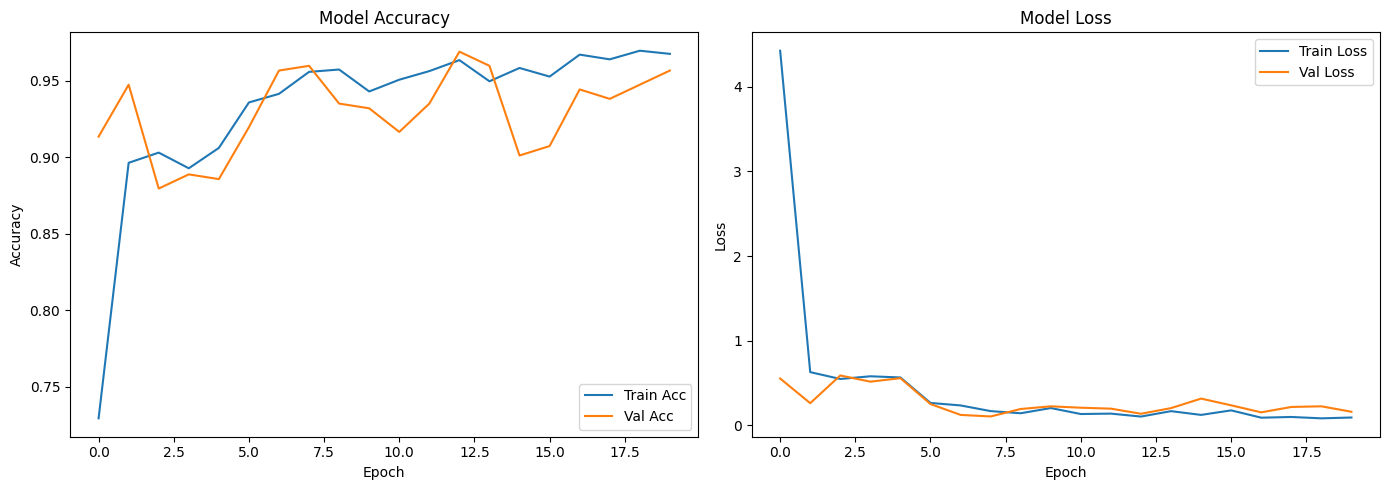

In [ ]:
# Accuracy and loss plots
plt.figure(figsize=(14, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


Saving the trained model

In [ ]:
disease_classifier.save('crop_disease_model.keras')  # if it's a Keras model


11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 602ms/step
Classification Report:
                       precision    recall  f1-score   support

 diseased cotton leaf       0.93      0.98      0.96        55
diseased cotton plant       0.98      0.95      0.96       101
    fresh cotton leaf       0.94      0.99      0.96        80
   fresh cotton plant       0.96      0.92      0.94        88

             accuracy                           0.96       324
            macro avg       0.95      0.96      0.96       324
         weighted avg       0.96      0.96      0.96       324



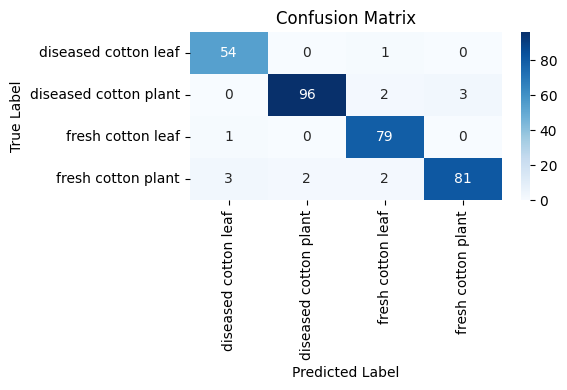

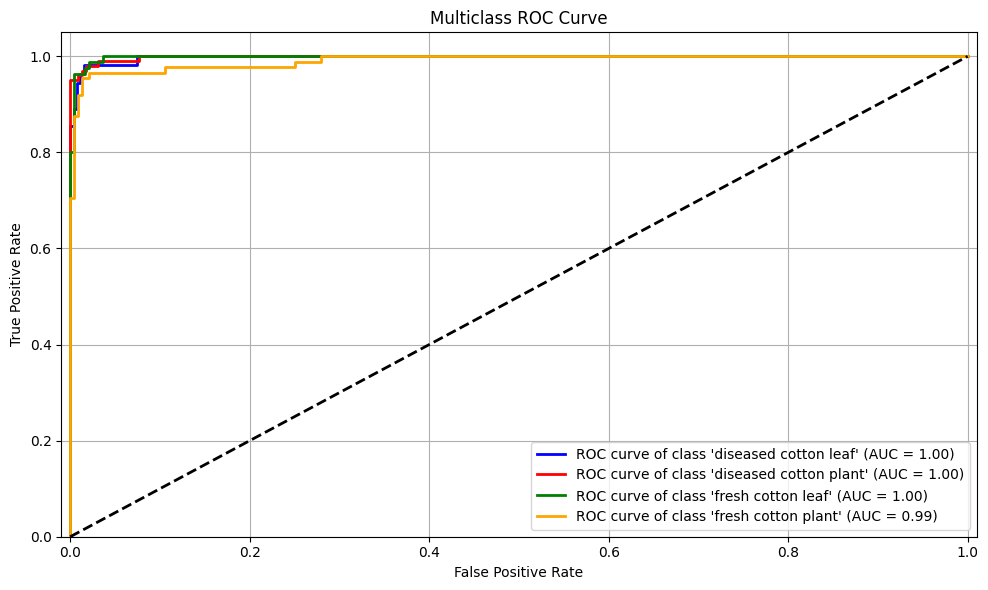

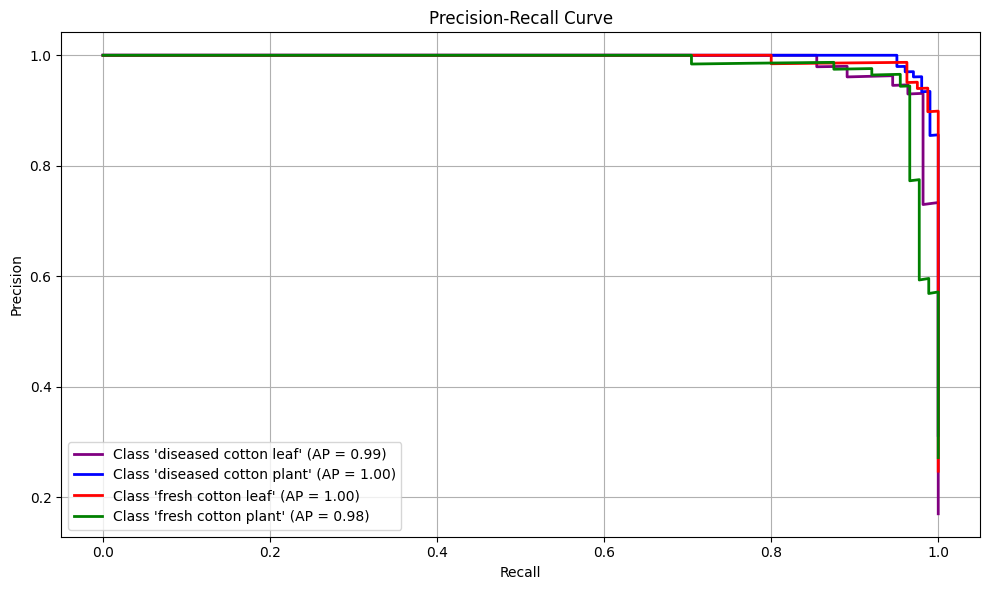

In [ ]:
import numpy as np

# Reset the validation generator
val_set.reset()

# Get predicted probabilities
y_pred_probs = disease_classifier.predict(val_set, verbose=1)

# Get true labels
y_true = val_set.classes

# Get predicted labels (argmax for multiclass)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class names
class_names = list(val_set.class_indices.keys())

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle

# One-hot encode true labels
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(class_names)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(10, 6))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

for i, color in zip(range(len(class_names)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"ROC curve of class '{class_names[i]}' (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


from sklearn.metrics import precision_recall_curve, average_precision_score

# Plot precision-recall curve for each class
plt.figure(figsize=(10, 6))
for i, color in zip(range(len(class_names)), colors):
    precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    ap_score = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])
    plt.plot(recall, precision, lw=2, color=color,
             label=f"Class '{class_names[i]}' (AP = {ap_score:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.show()
